# Bulldozer Sale Price Prediction
This project is from the [Kaggle Bluebook for Bulldozers competition](https://www.kaggle.com/competitions/bluebook-for-bulldozers/overview)

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.ensemble import RandomForestRegressor

## Problem Definition
Predicting Bulldozer sale price based on history data
* Since we are predicting the future sale price of the item, it is defined as a regression problem 

## Data
Data is downloaded from [Kaggle](https://www.kaggle.com/competitions/bluebook-for-bulldozers/data)

* Train.csv is the training set, which contains data through the end of 2011.
* Valid.csv is the validation set, which contains data from January 1, 2012 - April 30, 2012
* Test.csv is the test set, which contains data from May 1, 2012 - November 2012.

In [75]:
train_df = pd.read_csv("data/Train.csv")
valid_df = pd.read_csv("data/Valid.csv")
test_df = pd.read_csv("data/Test.csv")

/var/folders/mf/3wt3q1y17_3fr_j24qtf31bm0000gn/T/ipykernel_32895/1727769340.py:1: DtypeWarning: Columns (0: fiModelSeries, 1: Coupler_System, 2: Grouser_Tracks, 3: Hydraulics_Flow) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("data/Train.csv")


In [40]:
train_df.shape, valid_df.shape, test_df.shape

((401125, 53), (11573, 52), (12457, 52))

**Our dataset contains:**

Training data: 401125 entries

Valid data: 11573 records

Test data: 12457 observations

In [46]:
train_df.columns

Index(['SalesID', 'SalePrice', 'MachineID', 'ModelID', 'datasource',
       'auctioneerID', 'YearMade', 'MachineHoursCurrentMeter', 'UsageBand',
       'saledate', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc',
       'fiModelSeries', 'fiModelDescriptor', 'ProductSize',
       'fiProductClassDesc', 'state', 'ProductGroup', 'ProductGroupDesc',
       'Drive_System', 'Enclosure', 'Forks', 'Pad_Type', 'Ride_Control',
       'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension',
       'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics',
       'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size',
       'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow',
       'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb',
       'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type',
       'Travel_Controls', 'Differential_Type', 'Steering_Controls'],
      dtype='str')

**'SalePrice'** is our target, and the others are features

In [41]:
# Have a glance of the dataset
train_df.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1139246,66000,999089,3157,121,3.0,2004,68.0,Low,11/16/2006 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139248,57000,117657,77,121,3.0,1996,4640.0,Low,3/26/2004 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1139249,10000,434808,7009,121,3.0,2001,2838.0,High,2/26/2004 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1139251,38500,1026470,332,121,3.0,2001,3486.0,High,5/19/2011 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139253,11000,1057373,17311,121,3.0,2007,722.0,Medium,7/23/2009 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Evaluation
The evaluation [metric for this this competition](www.kaggle.com/competitions/bluebook-for-bulldozers/overview/evaluation) is **RMSE**(root mean squared log error) between the actual and predicted auction price.

## Feature

* There is a data Dictionary provided by [the competition](https://www.kaggle.com/competitions/bluebook-for-bulldozers/data)  

In [48]:
print(f"We have {len(train_df.columns)-1} features in our training dataset") # minus our target (i.e. SalePrice)

We have 52 features in our training dataset


## 1. Exploratory Data Analysis

In [77]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 401125 entries, 0 to 401124
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   SalesID                   401125 non-null  int64         
 1   SalePrice                 401125 non-null  int64         
 2   MachineID                 401125 non-null  int64         
 3   ModelID                   401125 non-null  int64         
 4   datasource                401125 non-null  int64         
 5   auctioneerID              380989 non-null  float64       
 6   YearMade                  401125 non-null  int64         
 7   MachineHoursCurrentMeter  142765 non-null  float64       
 8   UsageBand                 69639 non-null   str           
 9   saledate                  12457 non-null   datetime64[us]
 10  fiModelDesc               401125 non-null  str           
 11  fiBaseModel               401125 non-null  str           
 12  fiSecondaryDe

Seems like we have plenty of missing values. Also, some data types need to be transformed as regression models accepts numerical values exclusively.

Subsequently, I will go through features.

In [264]:
train_df['datasource'].value_counts()

datasource
132    260752
136     75491
149     26304
121     23979
172     14599
Name: count, dtype: int64

It turns out that there are 5 data source.
I suspect this feature matters much for the model.

* SalesID, MachineID, ModelID, auctioneerID are different identifiers.
    * Except for ModelID, the other IDs are unlikely to significantly affect our model. However, it needs to be verivied, so we will conduct a feature importance analysis to check whether this hypothesis holds true.
    * According to data dictionary, **ModelID** is associated with **fiModelDesc**. Thus, one of them could be dropped.
* Base on the data dictionary, **fiModelDesc** is Description of a unique machine model (see ModelID); concatenation of fiBaseModel & fiSecondaryDesc & fiModelSeries & fiModelDescriptor. Thus, 

In [351]:
# # Checking if fiModelDesc can be represented by ModelID
# # The result is correct

# n_rows = 5
# for _ in train_df['ModelID'].unique():
#     print(f"ModelID : {_}")
#     print(train_df[train_df['ModelID'] == _]['fiModelDesc'].head(n_rows))

fiModelDesc is checked that it can be represented by ModelID (see above cell)
I wanted to keep ModelID, and drop fiModelDesc. 

However, per data dictionary, the feature 'fiModelDesc' is concatenated by fiBaseModel & fiSecondaryDesc & fiModelSeries & fiModelDescriptor, so let me check how does the concatenation work.

In [130]:
# Checking the associateion among ModelID, 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc', 'fiModelSeries', 'fiModelSeries', and 'fiModelDescriptor'
train_df[['ModelID', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc', 'fiModelSeries', 'fiModelSeries', 'fiModelDescriptor' ]]

,ModelID,fiModelDesc,fiBaseModel,fiSecondaryDesc,fiModelSeries,fiModelSeries,fiModelDescriptor
0,3157,521D,521,D,NaN,NaN,NaN
1,77,950FII,950,F,II,II,NaN
2,7009,226,226,NaN,NaN,NaN,NaN
3,332,PC120-6E,PC120,NaN,-6E,-6E,NaN
4,17311,S175,S175,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
401120,21439,35NX2,35,NX,2,2,NaN
401121,21439,35NX2,35,NX,2,2,NaN
401122,21439,35NX2,35,NX,2,2,NaN
401123,21435,30NX,30,NX,NaN,NaN,NaN


ModelID appears to function as an encoder that represents fiModelDesc, which is formed by concatenating fiBaseModel, fiSecondaryDesc, fiModelSeries, and fiModelDescriptor.
Therefore, I decide to drop 'fiModelDesc', ‘fiBaseModel’, ‘fiSecondaryDesc’, ‘fiModelSeries’, and ‘fiModelDescriptor’ to avoid redundancy.

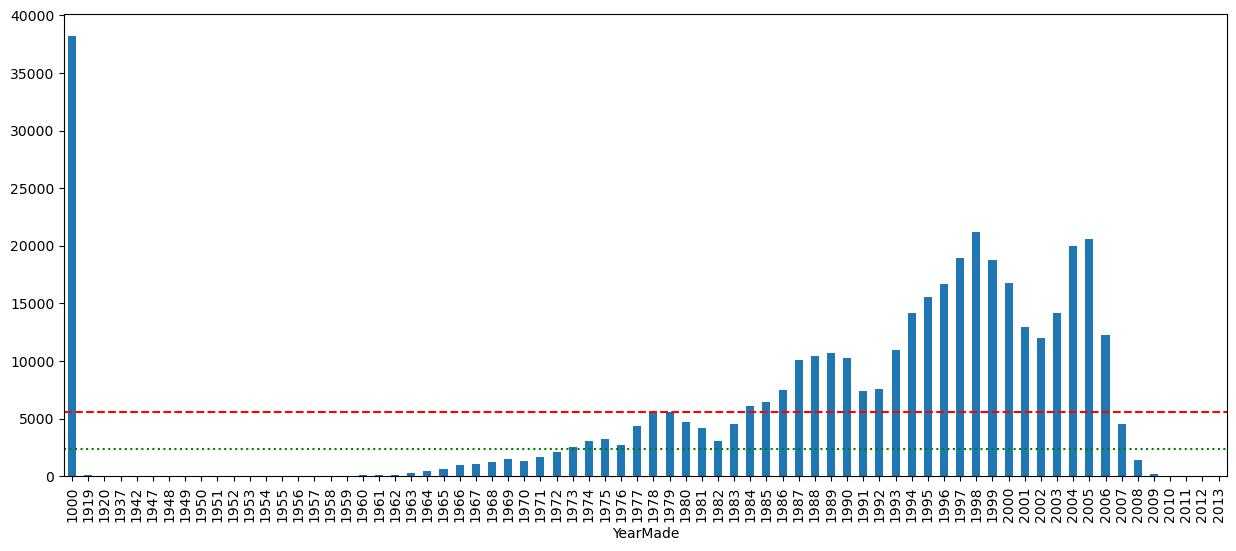

In [410]:
# Checking yearMade

fig = plt.figure(figsize = (15, 6))
fig = train_df['YearMade'].value_counts().sort_index().plot.bar()
plt.axhline(np.mean(train_df['YearMade'].value_counts()),
           linestyle = '--',
           c = 'red')
plt.axhline(np.median(train_df['YearMade'].value_counts()),
           linestyle = ':',
           c = 'green')

In [409]:
print(f"The proportion of products manufactured in the year 1000 is:  {train_df[train_df['YearMade'] == 1000].shape[0] /  train_df['YearMade'].shape[0] * 100:.2}%")

The proportion of products manufactured in the year 1000 is:  9.5%


The above bar graph provides several key insights as below:
1. Most products were made in the year 1000, which is abnormal.
2. Following the year 1000, 1999 is the second most common manufacture year.
3. The most manufacturing years occur in cycles of 10 to 15 years, with peaks in 1978, 1989, 1998, and 2005.

Let's explore the replationship between `YearMade` and `SalePrice`

<Axes: xlabel='YearMade'>

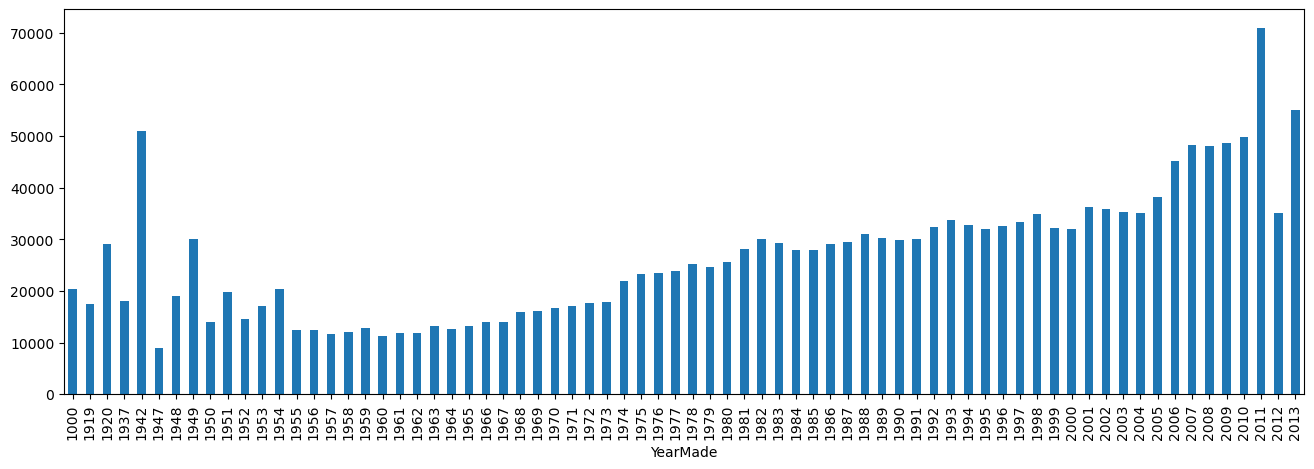

In [445]:
# Relationship between YearMade and SalePrice

train_df[train_df['YearMade'] == 1000]

train_df.groupby(["YearMade"]).mean(numeric_only = True).sort_values(by = "YearMade")['SalePrice'].plot.bar(figsize = (16, 5))

The bar graph shows the positive relationship between `YearMade` and `SalePrice`, which is also our target. The `SalePrice` increases with the bulldozer's manufacturing year.
Notably, 1942 shows the second-highest sale price, which is an unexpected peak.

Regarding the manufacturing year 1000, according to [this article](https://sitechrockymtn.com/blog/a-history-of-the-bulldozer/), it is apparetly recorded incorrectly as the first modern bulldozer was designed in 1923, and built in 1925. Thus, I may replace the year by inferring it from other entries with the same ModelID or simply fill it with `na` in the **Data pre-processing seccion**

**MachineHoursCurrentMeter:** 

current usage of the machine in hours at time of sale (saledate);  null or 0 means no hours have been reported for that sale

In [492]:
print(f"Missing values account for {(train_df[train_df['MachineHoursCurrentMeter'] == 0].shape[0] +  train_df['MachineHoursCurrentMeter'].isna().sum())/ train_df['MachineHoursCurrentMeter'].shape[0] * 100 :.2f} %")

Missing values account for 82.64 %


<Axes: >

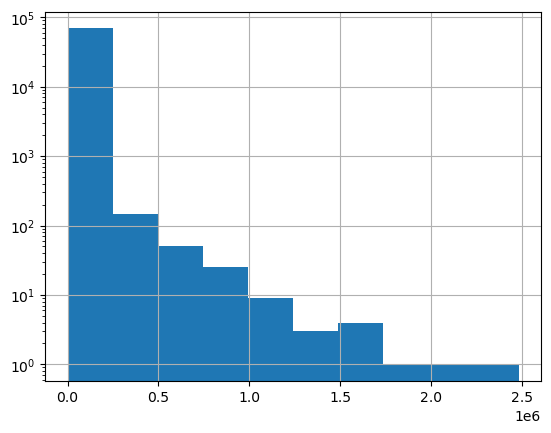

In [567]:
train_df[train_df['MachineHoursCurrentMeter'] > 0]['MachineHoursCurrentMeter'].hist(log = True)

Proportion of missing values in UsageBand : 82.64 %


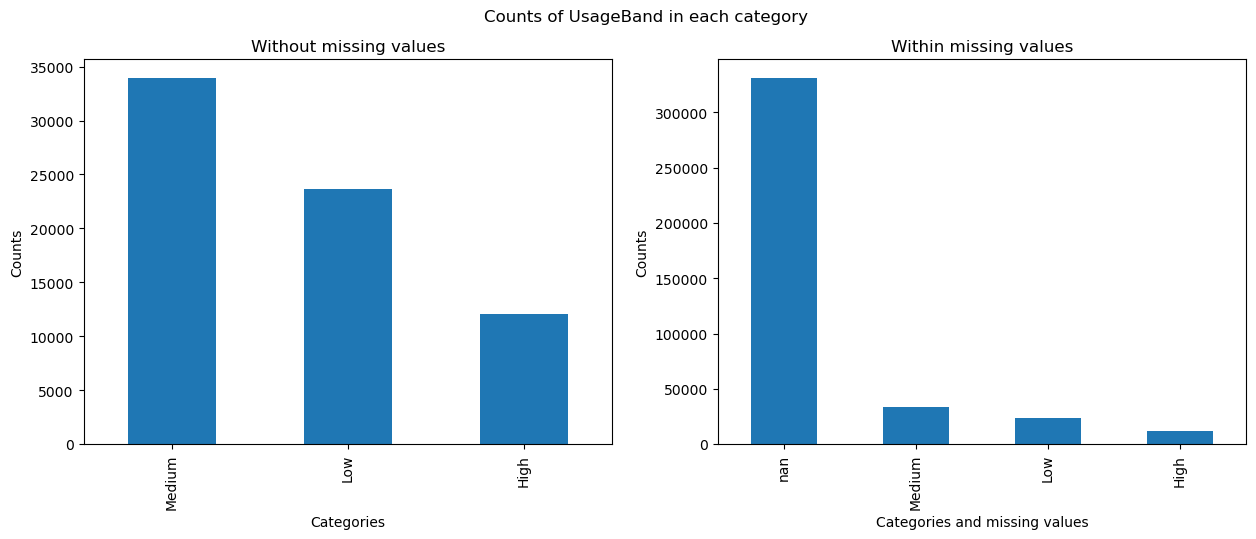

In [326]:
# UsageBand

print(f"Proportion of missing values in UsageBand : { train_df['UsageBand'].isna().sum() / train_df.shape[0] * 100 :.2f} %")

fig, (ax0, ax1) = plt.subplots(figsize = (15, 5),
                              nrows = 1,
                              ncols = 2)

train_df['UsageBand'].value_counts().plot.bar(ax = ax0)
ax0.set(title = "Without missing values",
       xlabel= "Categories",
       ylabel = "Counts")

train_df['UsageBand'].value_counts(dropna=False).plot.bar(ax = ax1)
ax1.set(title = "Within missing values",
        xlabel = "Categories and missing values",
        ylabel = "Counts")

fig.suptitle("Counts of UsageBand in each category");

In [598]:
False in train_df['UsageBand'].isna() == train_df['MachineHoursCurrentMeter'].isna()

# Seems like they share the same missing vlaues

False

In [599]:
pd.crosstab(train_df['UsageBand'], train_df['fiBaseModel'])

fiBaseModel,10,1080,1088,110,1105,112,115,1150,12,120,...,ZX350,ZX370,ZX450,ZX460,ZX50,ZX600,ZX70,ZX75,ZX80,ZX800
UsageBand,,,,,,,,,,,,,,,,,,,,,
High,0,0,0,1,0,0,14,0,105,29,...,34,13,64,1,0,9,0,1,0,5
Low,3,2,4,72,1,3,4,54,229,120,...,1,0,1,0,2,0,5,10,0,0
Medium,0,0,0,19,1,0,1,38,191,259,...,31,3,9,1,4,0,0,3,4,0


The majority of UsageBand is Medium. However, the proportion of missing values is up to 80%

* UsageBand is ordernal categorical. I will transform the datatype later.
* I will fill the missing data with "Medium"

Proportion of missing values in Productsize : 52.55 %


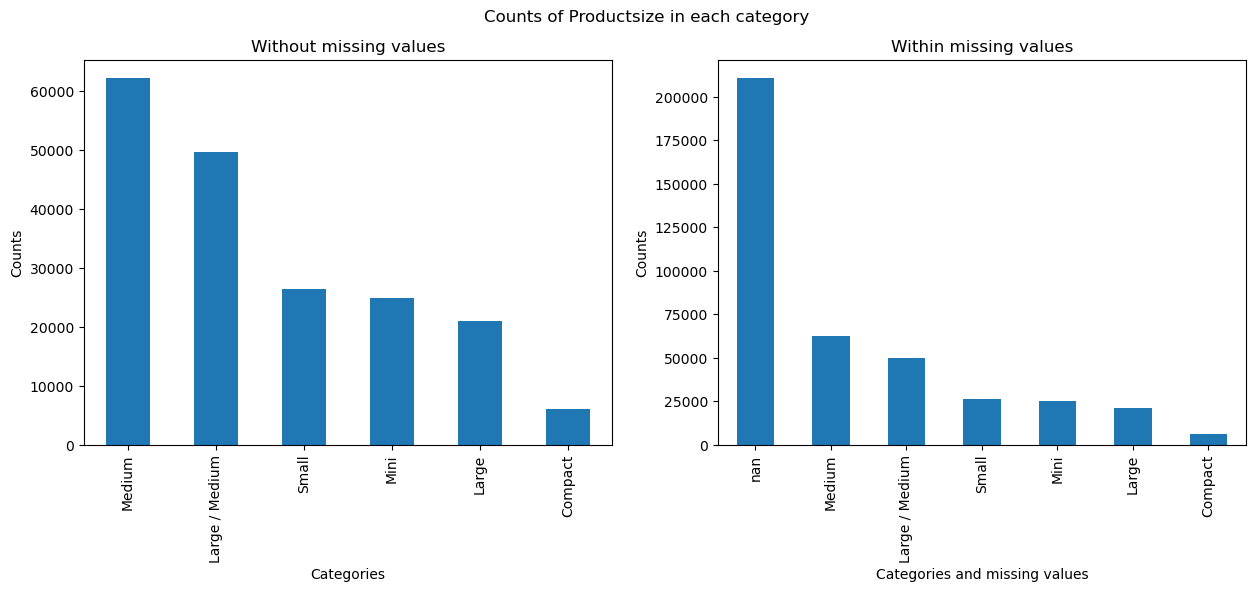

In [261]:
print(f"Proportion of missing values in Productsize : { train_df['ProductSize'].isna().sum() / train_df.shape[0] * 100 :.2f} %")
fig, (ax0, ax1) = plt.subplots(figsize = (15, 5),
                              nrows = 1,
                              ncols = 2)

train_df['ProductSize'].value_counts().plot.bar(ax = ax0)
ax0.set(title = "Without missing values",
       xlabel= "Categories",
       ylabel = "Counts")

train_df['ProductSize'].value_counts(dropna=False).plot.bar(ax = ax1)
ax1.set(title = "Within missing values",
        xlabel = "Categories and missing values",
        ylabel = "Counts")

fig.suptitle("Counts of Productsize in each category");

The following insights are derived from the bar graphs above:

* Missing values in ProductSize account for up to more than half of the training dataset. In other word, we have less than half data in this feature.
* In terms of **Large/Medium** category, it appears to indicate uncertainty as to whether the instance should be classified as Large or Medium
* Medium size appears to have the highest frequency.

Given that the most products fall into the Medium category, missing values will be imputed accordingly.

In [611]:
train_df['ProductGroup'].unique(), train_df['ProductGroupDesc'].unique()

(<ArrowStringArray>
 ['WL', 'SSL', 'TEX', 'BL', 'TTT', 'MG']
 Length: 6, dtype: str,
 <ArrowStringArray>
 [       'Wheel Loader',  'Skid Steer Loaders',    'Track Excavators',
      'Backhoe Loaders', 'Track Type Tractors',       'Motor Graders']
 Length: 6, dtype: str)

Basically, ProductGroup is the abbreviation of ProductGroupDesc, so I will drop ProductGroupDesc

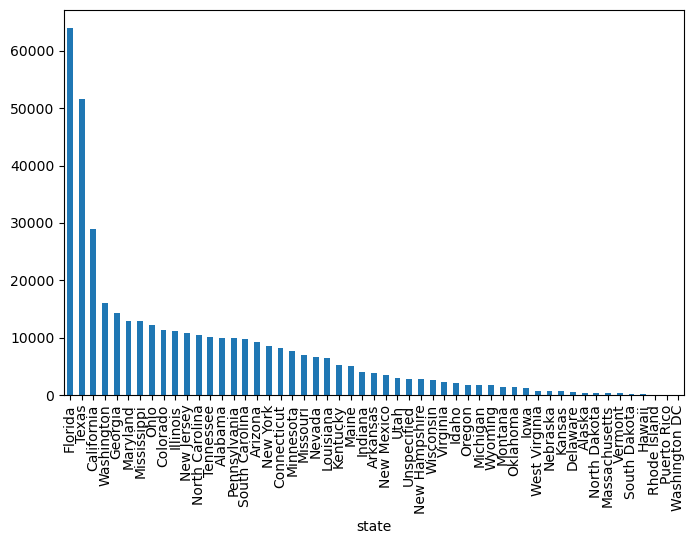

In [620]:
train_df['state'].value_counts().plot.bar(figsize = (8,5));

The demand for Bulldozer in Forida, Texas, California is higher than the other states based on the bargraph above.
Let's check if this related to saleprice.

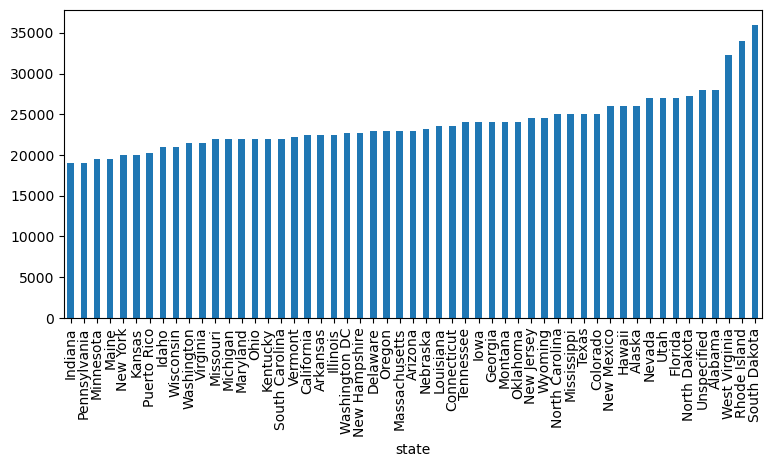

In [643]:
train_df.groupby(['state'])['SalePrice'].median().sort_values().plot.bar(figsize = (9, 4));

Interestingly, the sale price remains unaffected despite the high demand in those states.

There are 73.98% missing data in Drive System
Not sure what does "No" mean. I think I will keep it, and convert this feature to category


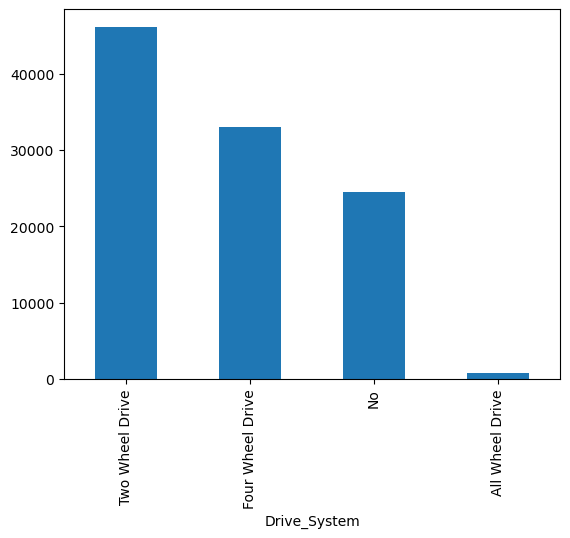

In [661]:
print(f"There are {train_df['Drive_System'].isna().sum() / train_df['Drive_System'].shape[0] * 100:.2f}% missing data in Drive System")
train_df['Drive_System'].value_counts().sort_values(ascending = False).plot.bar();

print("Not sure what does \"No\" mean. I think I will keep it, and convert this feature to category")

Enclosure_Type
None or Unspecified    21923
Low Profile             2510
High Profile             786
Name: count, dtype: int64


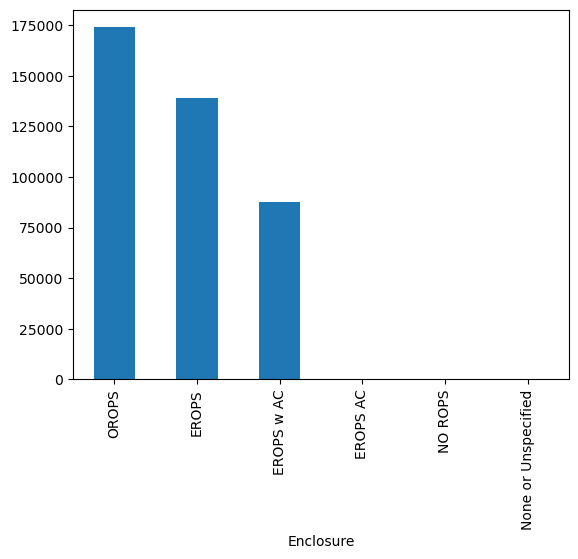

In [672]:
# Enclosure describes whether machine has an enclosed cab or not
# "Enclosure" is clearly related to "Enclosure_type". Therefore, I will drop "Enclosure_type", and then convert "Enclosure" to categorical data type
train_df['Enclosure'].value_counts().sort_values(ascending = False).plot.bar();
print(train_df['Enclosure_Type'].value_counts())

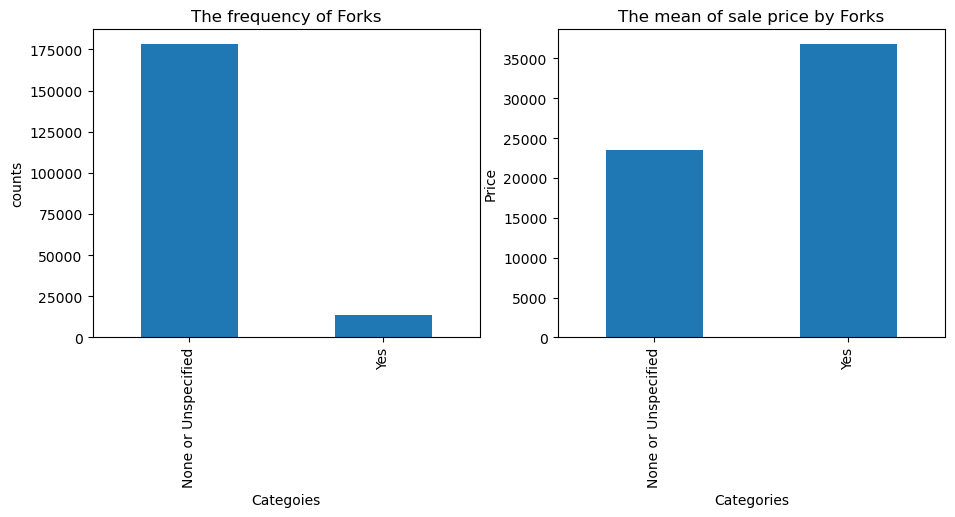

In [706]:
# This feature is a atachment used for lifting.
# The category None is mixed with missing value, and the data is seriously unbalanced.

fig, (ax0, ax1) = plt.subplots(figsize = (11,4),
                            ncols = 2,
                            nrows = 1)
train_df['Forks'].value_counts().plot.bar(ax = ax0)
ax0.set(title = "The frequency of Forks",
       xlabel= "Categoies",
       ylabel= "counts")

train_df.groupby('Forks')['SalePrice'].mean().plot.bar(ax = ax1)
ax1.set(title = "The mean of sale price by Forks",
       xlabel = "Categories",
       ylabel = "Price");

# I wanted to drop this feature initially, but the graph indicates that the sale price increases when the machine has Forks. Therefore, I will keep this feature, and conver it from str to category

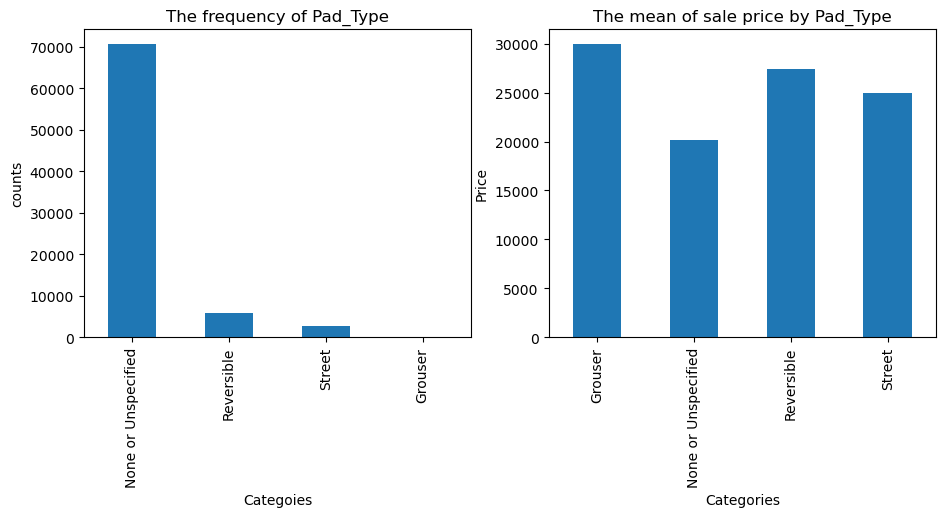

In [713]:
# Pad_Type represents type of treads a crawler machine uses

fig, (ax0, ax1) = plt.subplots(figsize = (11,4),
                            ncols = 2,
                            nrows = 1)
train_df['Pad_Type'].value_counts().plot.bar(ax = ax0)
ax0.set(title = "The frequency of Pad_Type",
       xlabel= "Categoies",
       ylabel= "counts")

train_df.groupby('Pad_Type')['SalePrice'].mean().plot.bar(ax = ax1)
ax1.set(title = "The mean of sale price by Pad_Type",
       xlabel = "Categories",
       ylabel = "Price");

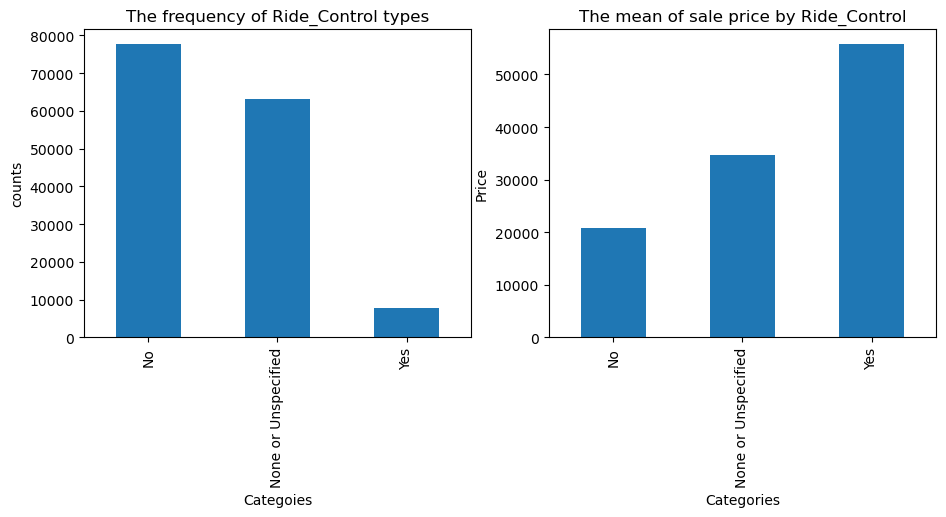

In [719]:
fig, (ax0, ax1) = plt.subplots(figsize = (11,4),
                            ncols = 2,
                            nrows = 1)
train_df['Ride_Control'].value_counts().plot.bar(ax = ax0)
ax0.set(title = "The frequency of Ride_Control types",
       xlabel= "Categoies",
       ylabel= "counts")

train_df.groupby('Ride_Control')['SalePrice'].mean().plot.bar(ax = ax1)
ax1.set(title = "The mean of sale price by Ride_Control",
       xlabel = "Categories",
       ylabel = "Price");

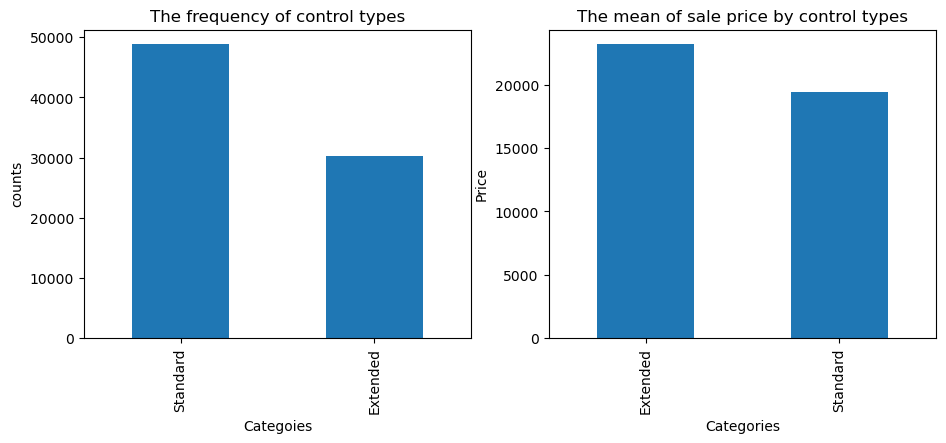

In [721]:
# Stick is type of control
fig, (ax0, ax1) = plt.subplots(figsize = (11,4),
                            ncols = 2,
                            nrows = 1)
train_df['Stick'].value_counts().plot.bar(ax = ax0)
ax0.set(title = "The frequency of control types",
       xlabel= "Categoies",
       ylabel= "counts")

train_df.groupby('Stick')['SalePrice'].mean().plot.bar(ax = ax1)
ax1.set(title = "The mean of sale price by control types",
       xlabel = "Categories",
       ylabel = "Price");

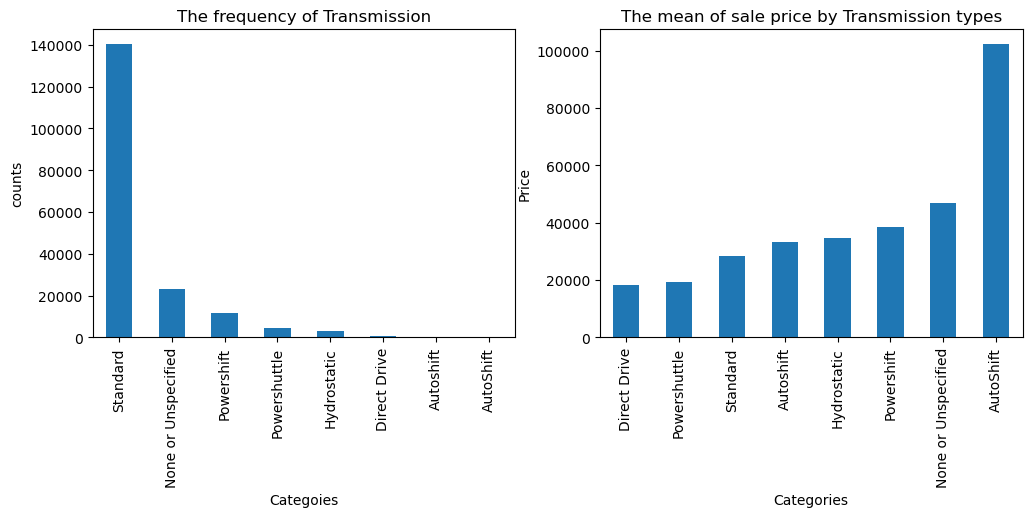

In [727]:
# type of transmission
# typically automatic or manual

fig, (ax0, ax1) = plt.subplots(figsize = (12,4),
                            ncols = 2,
                            nrows = 1)
train_df['Transmission'].value_counts().plot.bar(ax = ax0)
ax0.set(title = "The frequency of Transmission",
       xlabel= "Categoies",
       ylabel= "counts")

train_df.groupby('Transmission')['SalePrice'].mean().sort_values().plot.bar(ax = ax1)
ax1.set(title = "The mean of sale price by Transmission types",
       xlabel = "Categories",
       ylabel = "Price");

# Autoshift has the highest sale price despites it accounts the least proportion of machine.
# There are 2 Autoshift, I think they should be merged

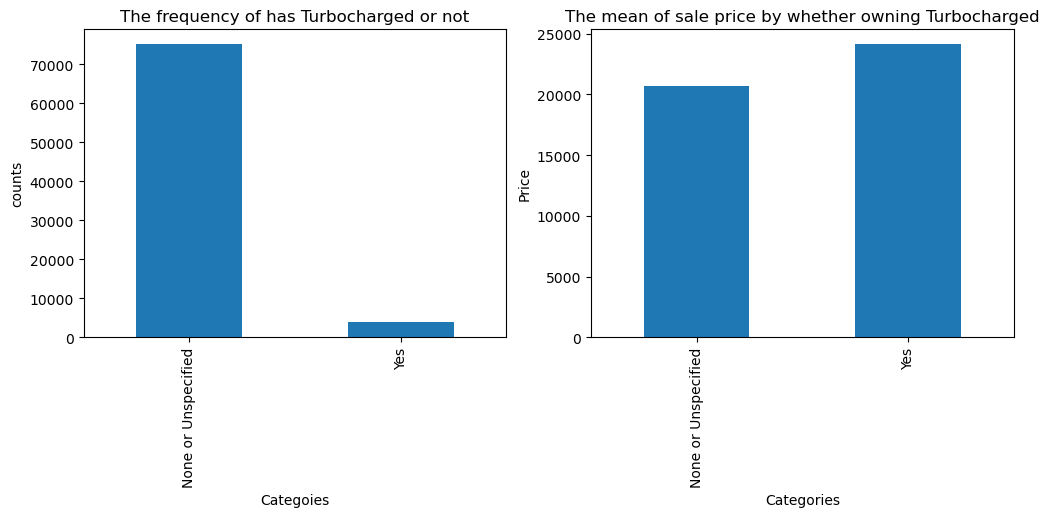

In [737]:
# Engine naturally aspirated or turbocharged. 
# In other word, if the machine has turbocharged.

fig, (ax0, ax1) = plt.subplots(figsize = (12,4),
                            ncols = 2,
                            nrows = 1)
train_df['Turbocharged'].value_counts().plot.bar(ax = ax0)
ax0.set(title = "The frequency of has Turbocharged or not",
       xlabel= "Categoies",
       ylabel= "counts")

train_df.groupby('Turbocharged')['SalePrice'].mean().sort_values().plot.bar(ax = ax1)
ax1.set(title = "The mean of sale price by whether owning Turbocharged",
       xlabel = "Categories",
       ylabel = "Price");

# Autoshift has the highest sale price despites it accounts the least proportion of machine.
# There are 2 Autoshift, I think they should be merged

In [740]:
 train_df['Blade_Extension'].value_counts()

Blade_Extension
None or Unspecified    24692
Yes                      527
Name: count, dtype: int64

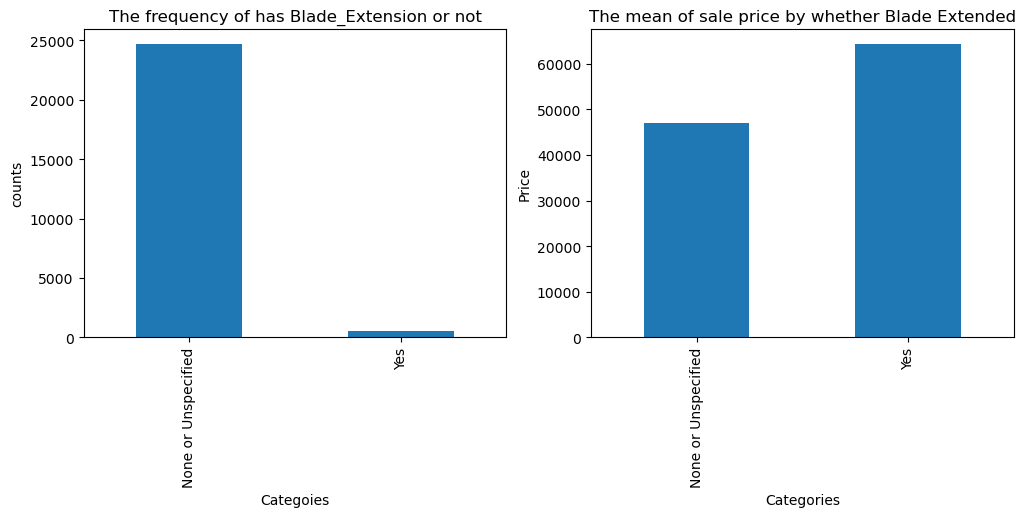

In [741]:
fig, (ax0, ax1) = plt.subplots(figsize = (12,4),
                            ncols = 2,
                            nrows = 1)
train_df['Blade_Extension'].value_counts().plot.bar(ax = ax0)
ax0.set(title = "The frequency of has Blade_Extension or not",
       xlabel= "Categoies",
       ylabel= "counts")

train_df.groupby('Blade_Extension')['SalePrice'].mean().sort_values().plot.bar(ax = ax1)
ax1.set(title = "The mean of sale price by whether Blade Extended",
       xlabel = "Categories",
       ylabel = "Price");

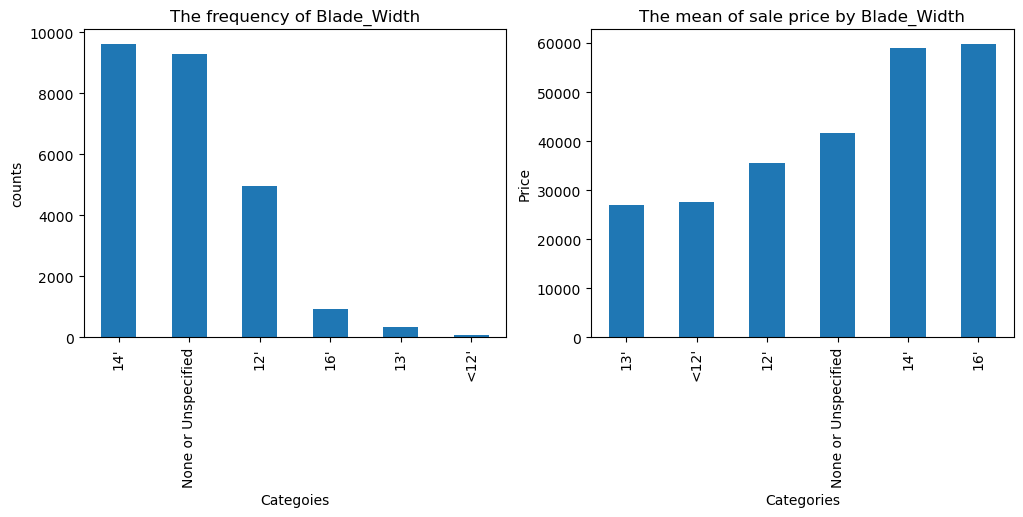

In [744]:
train_df['Blade_Width'].value_counts()

fig, (ax0, ax1) = plt.subplots(figsize = (12,4),
                            ncols = 2,
                            nrows = 1)
train_df['Blade_Width'].value_counts().plot.bar(ax = ax0)
ax0.set(title = "The frequency of Blade_Width",
       xlabel= "Categoies",
       ylabel= "counts")

train_df.groupby('Blade_Width')['SalePrice'].mean().sort_values().plot.bar(ax = ax1)
ax1.set(title = "The mean of sale price by Blade_Width",
       xlabel = "Categories",
       ylabel = "Price");

Engine_Horsepower
No          23937
Variable     1282
Name: count, dtype: int64


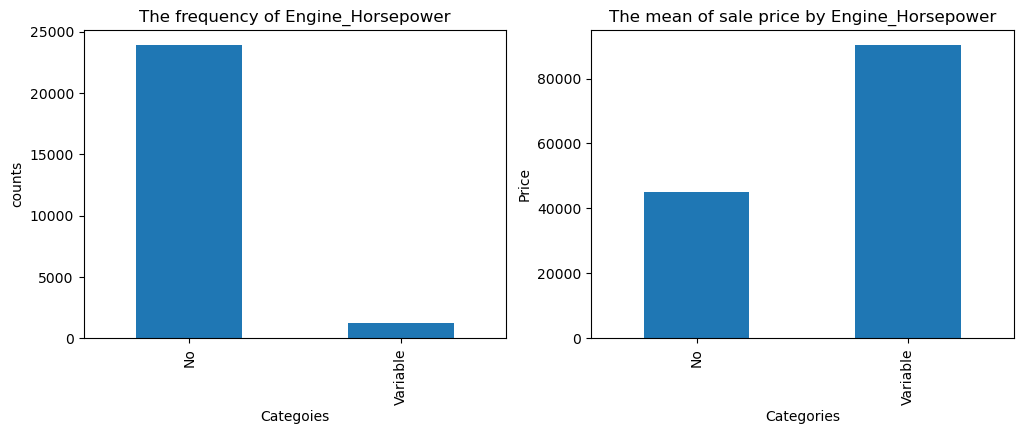

In [763]:
print(train_df['Engine_Horsepower'].value_counts())

fig, (ax0, ax1) = plt.subplots(figsize = (12,4),
                            ncols = 2,
                            nrows = 1)
train_df['Engine_Horsepower'].value_counts().plot.bar(ax = ax0)
ax0.set(title = "The frequency of Engine_Horsepower",
       xlabel= "Categoies",
       ylabel= "counts")

train_df.groupby('Engine_Horsepower')['SalePrice'].mean().sort_values().plot.bar(ax = ax1)
ax1.set(title = "The mean of sale price by Engine_Horsepower",
       xlabel = "Categories",
       ylabel = "Price");

## Data Pre-processing

* drop features - `fiModelDesc`, `fiBaseModel`, `fiSecondaryDesc`, `fiModelSeries`, `fiModelDescriptor`, `ProductGroupDesc`, `Enclosure_type`
* Transforming Data type
    * `YearMade` -> datetime
    * `UsageBand` -> ordernal category
    * `saledate` -> datetime
    * `ProductSize` -> ordernal category
    * `ProductGroup` -> ordernal category
    * `Drive_System` -> category
    * `Enclosure` -> category
    * `Forks` -> category (0 or 1)
    * `Pad_Type` -> category
    * `Ride_Control` -> category (0 or 1)
    * `Stick` -> category (0 or 1)
    * `Transmission` -> category ( 0 or 1)
    * `Turbocharged` -> category (0 or 1)
    *  `Blade_Extension` -> category (0 or 1)
    *  `Blade_Width ` -> ordernal category
    *  `Engine_Horsepower` -> category (0 or 1)

* Handling Missing Values:
    * Missing values in `ProductSize` will be imputed with **Medium**
    * Missing values in `UsageBand` will be imputed with **Medium**
    * `YearMade`: Replacing the year 1000 to `na value` or the year by inferring it from other entries with the same ModelID
    * `Ride_Control` : Replacing **None or Unspecified** to `na value`
    * `Blade_Width` : Replacing **None or Unspecified** to `na value`

* Other
    * merge `train_df[train_df['Transmission'] == 'Autoshift']` and `train_df[train_df['Transmission'] == 'AutoShift']`

In [76]:
train_df['saledate'] = pd.to_datetime(test_df['saledate'])
train_df['saledate']

0        2012-05-03
1        2012-05-10
2        2012-05-10
3        2012-05-10
4        2012-05-10
            ...    
401120          NaT
401121          NaT
401122          NaT
401123          NaT
401124          NaT
Name: saledate, Length: 401125, dtype: datetime64[us]

In [ ]:
#YearMade

train_df[train_df['YearMade'] == 1000]['ModelID'].unique()
train_df[train_df['ModelID'] == 5857]['YearMade']